In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
sys.path.insert(1, '../')

In [2]:
import pyFBS

from scipy import sparse
from xarray import DataArray
from scipy.sparse.linalg import eigsh
import numpy as np

import pyvista as pv
import pyansys

from pyFBS.utility import *


In [3]:
stl = r'C:\Users\tomaz.bregar\Desktop\git_projects\svd_decoupling\MK_files\AB_n.stl'
xlsx = r'C:\Users\tomaz.bregar\Desktop\git_projects\svd_decoupling\MK_files\GEO_SIM_v3.xlsx'

In [4]:
full_file = r'C:\Users\tomaz.bregar\Desktop\git_projects\svd_decoupling\MK_files\AB\file.full'
ress_file = r'C:\Users\tomaz.bregar\Desktop\git_projects\svd_decoupling\MK_files\AB\file.rst'

MK = pyFBS.MK_model(ress_file,full_file,no_modes = 100)

In [54]:
view3D = pyFBS.display.view3D()
view3D.add_stl(stl,name = "engine_mount",color = "#8FB1CC",opacity = 0.2)

In [60]:
from pathlib import Path

p = Path(pyFBS.__file__).parents[1] 

str(p)+os.sep+"data" +os.sep 

'..\\data\\'

In [6]:
point_cloud = pv.PolyData(MK.nodes*1000)
mesh_actor = view3D.plot.add_mesh(point_cloud,scalars = np.zeros(point_cloud.points.shape[0]) ,color = "k",name = "mesh",cmap = "viridis",render_points_as_spheres = True,point_size=1.5)
pts = point_cloud.points.copy()

In [7]:
# Priprava animacije oblike
select_mode = 50      
relative_scale = 30

#kreairanje animacije
_modeshape = np.zeros_like(MK.nodes)
for ref,mode in zip(MK.dof_ref,MK.eigen_vec[:,select_mode]):
    _modeshape[ref[0]-1,ref[1]] = mode

#samo priprava vsega za onimacijo v pyFBSu
mode_dict = dict()
mode_dict["animation_pts"] = mode_animation(_modeshape,relative_scale,no_points = 60)
mode_dict["mesh"] = point_cloud
mode_dict["or_pts"] = pts
mode_dict["scalars"] = True
mode_dict["fps"] = 30

#dodajanje animacije v okno
view3D.add_modeshape(mode_dict,run_animation = True)

In [8]:
df_imp = pd.read_excel(xlsx, sheet_name='Impacts_AB')
view3D.show_imp(df_imp)
#df_imp

In [10]:
df_chn = pd.read_excel(xlsx, sheet_name='Channels_AB')
view3D.show_chn(df_chn)
#df_chn

In [27]:
MK.FRF_synth(df_chn,df_imp,f_end = 2000)

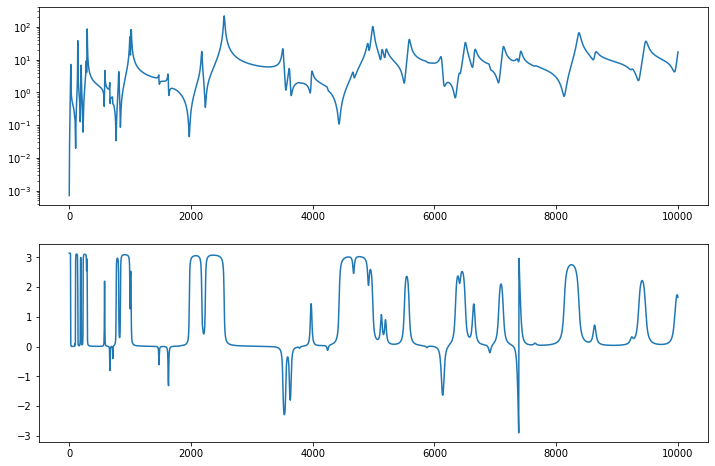

In [12]:
plt.figure(figsize = (12,8))
plt.subplot(211)
plt.semilogy(MK.freq,np.abs(MK.FRF[0,0]))
#plt.semilogy(freq,np.abs(FRF[-2,-1]),'--')

plt.subplot(212)
plt.plot(MK.freq,np.angle(MK.FRF[0,0]))
#plt.plot(freq,np.angle(FRF[2,0]),'--')

In [14]:
vpt = pyFBS.VPT(xlsx, ch="Channels_AB", refch="Impacts_AB", vp_ch = "VP Channels" ,vp_refch = "VP RefChannels")

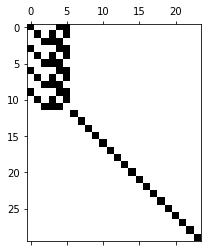

In [15]:
plt.spy(vpt.Rf)

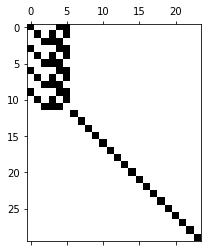

In [16]:
plt.spy(vpt.Ru)

In [30]:
vpt.apply_VPT(MK.freq,MK.FRF)


In [31]:
vpt.consistency([1],[1])
vpt.specific_impact.shape

(12,)

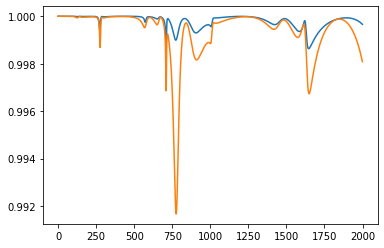

In [32]:
plt.plot(vpt.overall_impact)
plt.plot(vpt.overall_sensor)

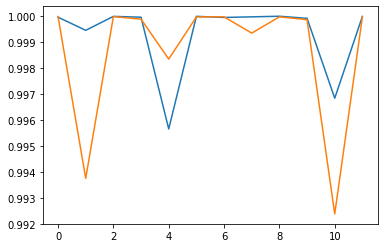

In [33]:
plt.plot(vpt.specific_impact)
plt.plot(vpt.specific_sensor)

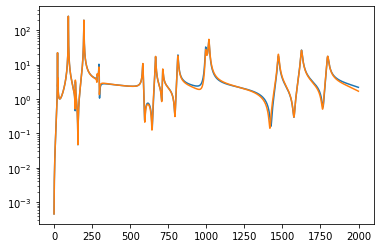

In [34]:
plt.semilogy(np.abs(vpt.y_f[1]))
plt.semilogy(np.abs(vpt.y[1]))

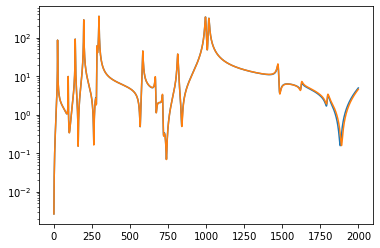

In [35]:
plt.semilogy(np.abs(vpt.u_f[0]))
plt.semilogy(np.abs(vpt.u[0]))

0.7773216824933171


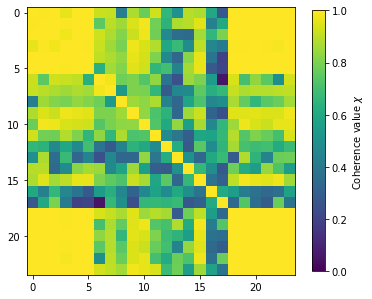

In [36]:
plt.figure(figsize = (6,6))
coh_val = np.zeros((24,24))

for i in range(24):
    for j in range(24):
        coh_val[i,j] = coh_frf(vpt.vptData[i,j],vpt.vptData[j,i])



plt.imshow(coh_val)
plt.colorbar(shrink = 0.8,label = "Coherence value $\chi$")

plt.clim(0,1)
print(np.mean(coh_val))

In [37]:
vpt.overall_sensor.shape

(2000,)

In [53]:

import pkg_resources

DATA_PATH = pkg_resources.resource_filename('pyFBS', 'data/LADISK_beam')



'..\\pyFBS\\data\\LADISK_beam'

In [46]:
src = os.path.join(os.dirname(mymodule.__file__), 'data/1.txt')

AttributeError: module 'os' has no attribute 'dirname'

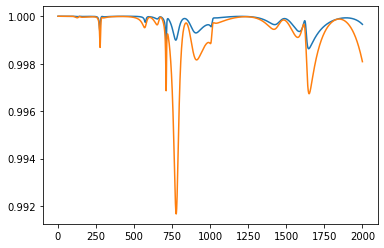

In [47]:
plt.plot(MK.freq,vpt.overall_impact)
plt.plot(MK.freq,vpt.overall_sensor)


In [ ]:
def f(i,j):
    plt.figure(figsize = (10,6))
    plt.subplot(211)
    plt.semilogy(MK.freq,np.abs(vpt.vptData[i,j]))
    plt.semilogy(MK.freq,np.abs(vpt.vptData[j,i]))
    plt.subplot(212)
    plt.plot(MK.freq,np.angle(vpt.vptData[i,j]))
    plt.plot(MK.freq,np.angle(vpt.vptData[j,i]))

f(5,2)